In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Epoch 1/2
37/37 ━━━━━━━━━━━━━━━━━━━━ 555s 14s/step - accuracy: 0.6793 - loss: 0.6364 - val_accuracy: 0.6690 - val_loss: 0.6121
Epoch 2/2
37/37 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.6963 - loss: 0.6003 - val_accuracy: 0.6690 - val_loss: 0.5911


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


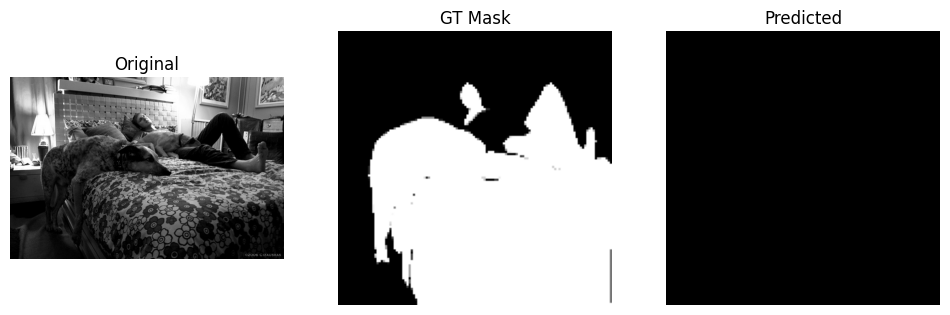

In [9]:
import os, random, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 128
BATCH = 8
EPOCHS = 2

TRAIN_IMG = "/content/drive/MyDrive/coco20k/train/images"
TRAIN_MASK = "/content/drive/MyDrive/coco20k/train/masks"
VAL_IMG = "/content/drive/MyDrive/coco20k/val/images"
VAL_MASK = "/content/drive/MyDrive/coco20k/val/masks"

train_files = os.listdir(TRAIN_IMG)[:300]
val_files = os.listdir(VAL_IMG)[:50]

def load_batch(img_dir, mask_dir, files):
    imgs, masks = [], []
    for f in files:
        p = os.path.join(img_dir, f)
        m = os.path.join(mask_dir, f.rsplit('.',1)[0] + ".png")
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))/255.0
        mask = cv2.imread(m,cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))
        mask = (mask>0).astype("float32")
        imgs.append(img)
        masks.append(mask[...,None])
    return np.array(imgs), np.array(masks)

class DataGen(tf.keras.utils.Sequence):
    def __init__(self, img_dir, mask_dir, files, batch=BATCH):
        self.img_dir=img_dir; self.mask_dir=mask_dir
        self.files=files; self.batch=batch
    def __len__(self): return len(self.files)//self.batch
    def __getitem__(self,idx):
        batch_files=self.files[idx*self.batch:(idx+1)*self.batch]
        return load_batch(self.img_dir,self.mask_dir,batch_files)

def conv(x,f):
    x=layers.Conv2D(f,3,padding="same",activation="relu")(x)
    x=layers.Conv2D(f,3,padding="same",activation="relu")(x)
    return x

def build_unet():
    inp=layers.Input((IMG_SIZE,IMG_SIZE,3))
    c1=conv(inp,32); p1=layers.MaxPooling2D()(c1)
    c2=conv(p1,64); p2=layers.MaxPooling2D()(c2)
    c3=conv(p2,128)
    u1=layers.UpSampling2D()(c3); u1=layers.Concatenate()([u1,c2])
    c4=conv(u1,64)
    u2=layers.UpSampling2D()(c4); u2=layers.Concatenate()([u2,c1])
    c5=conv(u2,32)
    out=layers.Conv2D(1,1,activation="sigmoid")(c5)
    return models.Model(inp,out)

train_gen = DataGen(TRAIN_IMG, TRAIN_MASK, train_files)
val_gen = DataGen(VAL_IMG, VAL_MASK, val_files)

model = build_unet()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS)

model.save("/content/drive/MyDrive/unet_task4_final.h5")

sample = random.choice(val_files)
img_p = os.path.join(VAL_IMG, sample)
mask_p = os.path.join(VAL_MASK, sample.rsplit('.',1)[0] + ".png")

orig=cv2.imread(img_p)
orig=cv2.cvtColor(orig,cv2.COLOR_BGR2RGB)
inp=cv2.resize(orig,(IMG_SIZE,IMG_SIZE))/255.0

pred=model.predict(np.expand_dims(inp,0))[0]
pred=(pred[:,:,0]>0.5).astype("uint8")*255

gt=cv2.imread(mask_p,cv2.IMREAD_GRAYSCALE)
gt=cv2.resize(gt,(IMG_SIZE,IMG_SIZE))

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(orig); plt.axis("off"); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(gt,cmap="gray"); plt.axis("off"); plt.title("GT Mask")
plt.subplot(1,3,3); plt.imshow(pred,cmap="gray"); plt.axis("off"); plt.title("Predicted")
plt.show()
